In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [2]:
pretrained_net = torchvision.models.resnet18(pretrained=True)
list(pretrained_net.children())[-3:]

c:\Users\PC_ATIC_01\dog-breed-identification\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PC_ATIC_01\dog-breed-identification\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), 

In [3]:
net = nn.Sequential(*list(pretrained_net.children())[:-2])

In [4]:
X = torch.rand(size=(1, 3, 320, 480))
net(X).shape

torch.Size([1, 512, 10, 15])

In [5]:
num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32))

In [6]:
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

In [7]:
conv_trans = nn.ConvTranspose2d(3, 3, kernel_size=4, padding=1, stride=2,
                                bias=False)
conv_trans.weight.data.copy_(bilinear_kernel(3, 3, 4));

Downloaded to: ../data\catdog.jpg


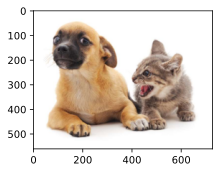

Image tensor shape: torch.Size([1, 3, 561, 728])


C:\Users\PC_ATIC_01\AppData\Local\Temp\ipykernel_15328\2064345902.py:25: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()


In [10]:
import os
import torch
import d2l.torch as d2l

# Create img folder if it doesn't exist
os.makedirs('../img/', exist_ok=True)

# Download from d2l repository
d2l.DATA_HUB['catdog'] = (d2l.DATA_URL + 'catdog.jpg', 
                           'c7e470db3935713eaa633f792172ea37')

# Download and get filename
fname = d2l.download('catdog')
print(f"Downloaded to: {fname}")

# Read the image
d2l.set_figsize()
img = d2l.plt.imread(fname)
d2l.plt.imshow(img)
d2l.plt.show()

# Convert numpy array to tensor and rearrange dimensions
# img is HxWx3 (Height, Width, Channels)
# We need CxHxW (Channels, Height, Width)
img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()

print(f"Image tensor shape: {img_tensor.shape}")  # Should be (1, 3, H, W)

# Now use it
X = img_tensor
Y = conv_trans(X)
out_img = Y[0].permute(1, 2, 0).detach()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


input image shape (with batch): torch.Size([1, 3, 561, 728])
input image value range: [0.0000, 255.0000]


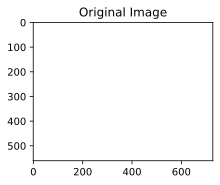

output image shape: torch.Size([1122, 1456, 3])
output image value range (before normalization): [0.5625, 255.0000]
output image value range (after normalization): [0.0000, 1.0000]


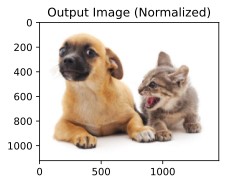

In [17]:
import os
import torch
import numpy as np
import d2l.torch as d2l

# Create img folder if it doesn't exist
os.makedirs('../img/', exist_ok=True)

# Download from d2l repository
d2l.DATA_HUB['catdog'] = (d2l.DATA_URL + 'catdog.jpg', 
                           'c7e470db3935713eaa633f792172ea37')

# Download and get filename
fname = d2l.download('catdog')

# Read as numpy first
img_np = d2l.plt.imread(fname)

# Convert to tensor (this is your input)
img = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float()

print(f'input image shape (with batch): {img.shape}')
print(f'input image value range: [{img.min():.4f}, {img.max():.4f}]')

# Display original
d2l.set_figsize()
d2l.plt.imshow(img[0].permute(1, 2, 0))
d2l.plt.title('Original Image')
d2l.plt.show()

# Apply convolution transpose
X = img
Y = conv_trans(X)
out_img = Y[0].permute(1, 2, 0).detach()

print(f'output image shape: {out_img.shape}')
print(f'output image value range (before normalization): [{out_img.min():.4f}, {out_img.max():.4f}]')

# NORMALIZE to [0, 1] range
out_img_normalized = (out_img - out_img.min()) / (out_img.max() - out_img.min())

print(f'output image value range (after normalization): [{out_img_normalized.min():.4f}, {out_img_normalized.max():.4f}]')

# Display normalized output
d2l.plt.imshow(out_img_normalized)
d2l.plt.title('Output Image (Normalized)')
d2l.plt.show()

In [14]:
W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

In [15]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = d2l.load_data_voc(batch_size, crop_size)

read 1114 examples
read 1078 examples


loss 0.425, train acc 0.867, test acc 0.845
6.6 examples/sec on [device(type='cpu')]


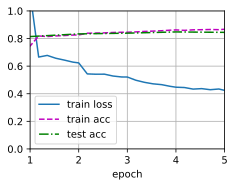

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import d2l.torch as d2l

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

num_epochs, lr, wd = 5, 0.001, 1e-3

# FIX: Use try_gpu() which handles CPU automatically
devices = [d2l.try_gpu()]  # Returns [cuda:0] or [cpu]
   
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

In [ ]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net(X.to(devices[0])).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

In [ ]:
def label2image(pred):
    colormap = torch.tensor(d2l.VOC_COLORMAP, device=devices[0])
    X = pred.long()
    return colormap[X, :]

In [ ]:
voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')
test_images, test_labels = d2l.read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
d2l.show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2);